In [1]:
import sys
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sys.path.append(os.path.abspath(".."))

from src.database import fetch_keystrokes_data
from src.features import extract_per_key_features

In [2]:
sns.set_theme(style="whitegrid", palette="muted")

In [3]:
df_raw = fetch_keystrokes_data()
df_raw = df_raw[df_raw['UserId'].str.strip() != '']

df_features = extract_per_key_features(df_raw)

### 1. Przygotowanie danych i Inżynieria Cech (Feature Engineering)

**Cel:** Pobranie surowych danych (czasów naciśnięć klawiszy) z bazy Neon i przetworzenie ich na postać wektorową (macierz), która jest wymagana przez algorytmy uczenia maszynowego (np. PCA i k-Means).

**Co zrobiliśmy?**
1. Odrzuciliśmy puste rekordy i anomalie (np. naciśnięcia klawiszy trwające ponad 1 sekundę, co sugeruje przerwę w pisaniu).
2. Wykorzystaliśmy funkcję `extract_per_key_features`, która przekształciła dane tak, aby kolumnami stały się konkretne klawisze (litery od `a` do `z` oraz `spacja`), a wartościami w wierszach - średni czas wciśnięcia (Dwell Time) dla danego użytkownika w danej próbce.
3. Ponieważ algorytmy bazujące na odległości (np. k-Means) są wrażliwe na skalę zmiennych, użyliśmy `StandardScaler`, aby ustandaryzować rozkłady cech (średnia 0, odchylenie standardowe 1).

**Interpretacja tabeli:**
Macierz wyjściowa (wyświetlona poniżej) zawiera przeskalowane czasy wciśnięć dla każdej litery alfabetu. Wartości dodatnie oznaczają, że w danej próbce użytkownik przytrzymał klawisz dłużej niż wynosi średnia dla całej populacji, a ujemne - krócej.

In [4]:
y_users = df_features['UserId']
X_keys = df_features.drop(columns=['UserId', 'SampleNumber'])

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_keys), columns=X_keys.columns)

display(X_scaled.head())

KeyPressed,,a,b,c,d,e,f,g,h,i,...,q,r,s,t,u,v,w,x,y,z
0,0.336753,0.478116,-0.153486,0.700578,0.518828,0.684954,0.476431,0.123028,0.494812,-0.349814,...,-0.622479,0.302185,0.419973,-0.156438,-0.294625,0.919922,-0.063205,-0.252118,-0.219174,-1.185444
1,-0.021019,0.434637,0.004655,0.066208,-0.310075,0.003600,0.641722,-0.049628,0.271381,0.063984,...,0.632056,0.500702,-0.031985,0.068378,-0.247559,0.510220,-0.085102,-0.252118,-0.171721,0.520236
2,-0.332798,-0.121293,1.930306,-0.343385,-0.198082,-0.065079,-0.839886,-1.580666,-1.140466,-0.206266,...,1.028018,-0.487897,0.264977,-0.482735,-0.250697,-0.837108,0.023776,-0.252118,-0.137996,0.828991
3,-0.471395,0.146747,0.358477,-0.115486,0.282224,0.354215,0.645228,0.526680,0.276949,-0.042415,...,-0.622479,0.397752,0.508457,-0.238292,-0.275798,0.518373,-0.590984,-0.252118,-0.365066,-1.185444
4,-0.272750,0.502858,0.344899,0.106168,-0.500936,-0.100644,-0.839886,0.462821,0.331507,-0.231521,...,-0.622479,-0.282028,-0.122677,-0.611036,0.261192,-0.837108,-0.442164,-0.252118,-0.602553,0.797990


### 2. Analiza Odległości (Euklidesa i Czebyszewa) - Weryfikacja unikalności

**Cel:** Zbadanie, jak bardzo podobne są do siebie próbki różnych osób oraz próbek tego samego użytkownika.

**Co zrobiliśmy?**
Obliczyliśmy odległość każdej próbki od każdej innej w naszej wielowymiarowej przestrzeni cech (gdzie każdy klawisz to jeden wymiar). Użyliśmy dwóch klasycznych metryk:
* **Odległość Euklidesa:** Standardowa "odległość w linii prostej".
* **Odległość Czebyszewa:** Odległość mierzona wzdłuż osi o największej różnicy.
Następnie wyciągnęliśmy średnią z tych odległości, dzieląc je na dwie grupy: porównania tej samej osoby oraz porównania różnych osób.

**Interpretacja wyników:**
Wyniki matematycznie udowadniają skuteczność biometrii klawiaturowej:
* Średnia odległość Euklidesa dla próbek **tej samej osoby to 3.91**, co oznacza relatywnie duże skupienie (próbki są do siebie podobne).
* Odległość dla **różnych osób wynosi 6.95**, co jest wartością niemal dwukrotnie wyższą. Wniosek: Różnice w dynamice pisania między ludźmi są znacznie większe niż naturalna zmienność u jednej osoby w czasie. Wskaźnik ten sugeruje, że odróżnienie użytkowników za pomocą algorytmów analitycznych jest wysoce wykonalne.

In [5]:
from scipy.spatial.distance import pdist, squareform

dist_euclidean = squareform(pdist(X_scaled, metric='euclidean'))
dist_chebyshev = squareform(pdist(X_scaled, metric='chebyshev'))

dist_df = pd.DataFrame({
    'Osoba_A': np.repeat(y_users.values, len(y_users)),
    'Osoba_B': np.tile(y_users.values, len(y_users)),
    'Euklides': dist_euclidean.flatten(),
    'Czebyszew': dist_chebyshev.flatten()
})

dist_df = dist_df[dist_df['Euklides'] > 0]
dist_df['Typ_Porównania'] = np.where(dist_df['Osoba_A'] == dist_df['Osoba_B'], 'Ta sama osoba', 'Różne osoby')

display(dist_df.groupby('Typ_Porównania')[['Euklides', 'Czebyszew']].mean())

,Euklides,Czebyszew
Typ_Porównania,,
Różne osoby,6.959343,2.679140
Ta sama osoba,3.913196,2.155268


### 3. Redukcja wymiarowości (PCA) - Znaczenie poszczególnych klawiszy

**Cel:** Wskazanie, które konkretne litery są najbardziej istotne dla rozróżniania poszczególnych osób, zgodnie z poleceniem prowadzącego.

**Co zrobiliśmy?**
Zastosowaliśmy Analizę Głównych Składowych (PCA - Principal Component Analysis). Skupiliśmy się na Pierwszej Składowej Głównej (PC1), ponieważ z definicji jest to wektor, wzdłuż którego wariancja (czyli różnice między użytkownikami) jest największa. Sprawdziliśmy absolutne wagi (tzw. ładunki - *loadings*) każdego klawisza w tej składowej. Im wyższa waga, tym mocniej dany klawisz przyczynia się do rozróżniania próbek.

**Interpretacja wyników:**
Z wykresu i zestawienia wynika, że klawisz **Spacja** jest najbardziej istotnym elementem odróżniającym poszczególnych użytkowników (najwyższa waga 0.228). Tuż za nim plasują się samogłoski `e`, `i`, `o` oraz litery `w`, `r`, `t`, `y` (często ze środkowej i górnej części klawiatury w układzie QWERTY). Wynika to z faktu, że spacja i samogłoski są najczęściej naciskanymi klawiszami, przez co utrwalają w sobie najbardziej stabilne i charakterystyczne nawyki motoryczne badanych (np. kciuk uderzający w spację z różną siłą).

=== WYJAŚNIONA WARIANCJA ===
PC1 tłumaczy: 65.63% różnic między próbkami
PC2 tłumaczy: 11.29% różnic między próbkami
Razem wymiar 2D tłumaczy: 76.92% wariancji



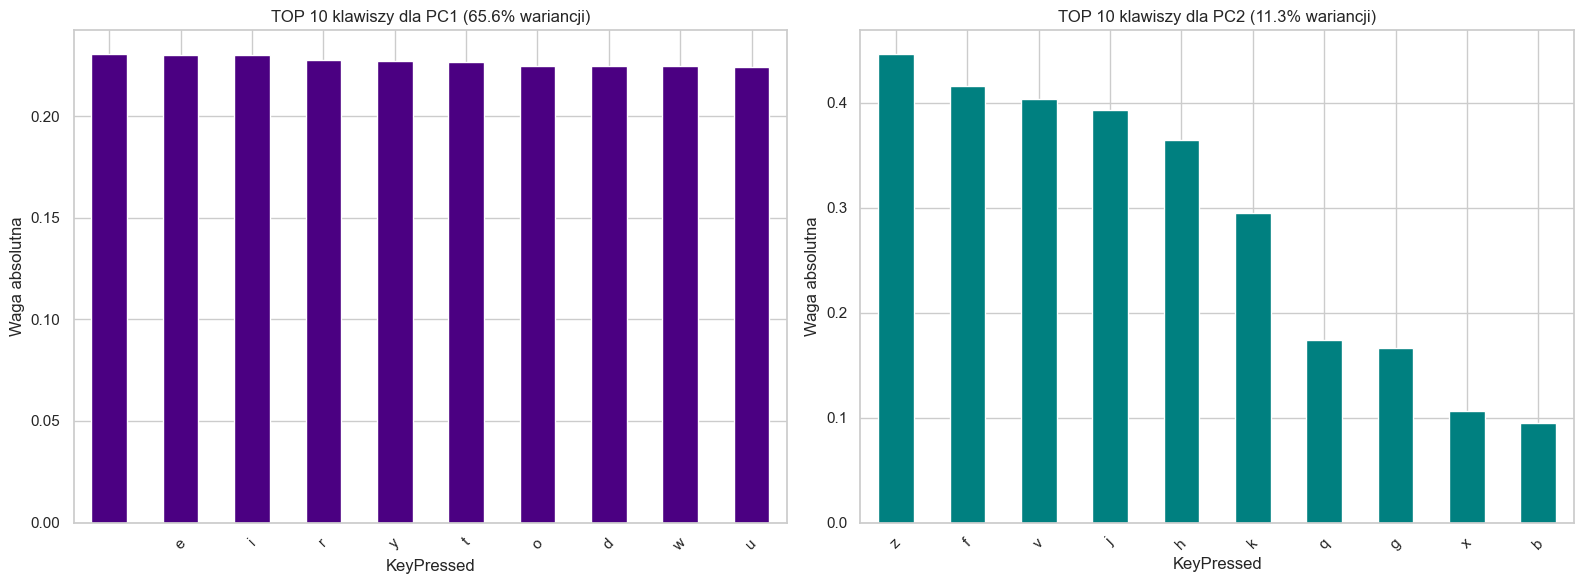

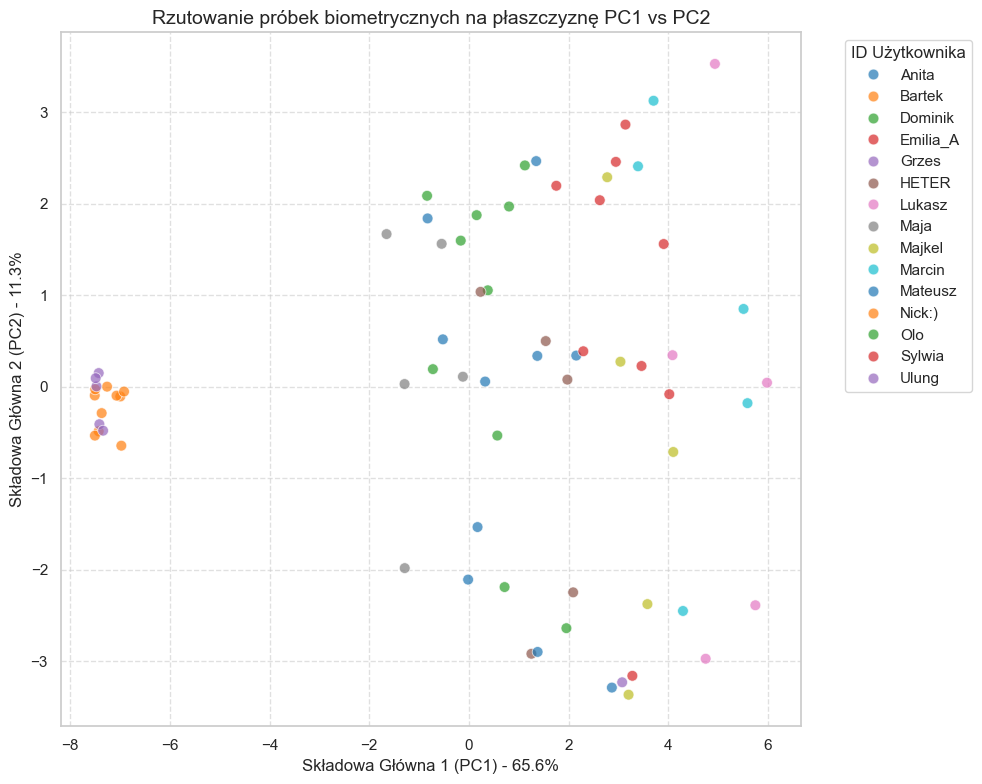

In [13]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled) 

var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

print(f"=== WYJAŚNIONA WARIANCJA ===")
print(f"PC1 tłumaczy: {var_pc1:.2f}% różnic między próbkami")
print(f"PC2 tłumaczy: {var_pc2:.2f}% różnic między próbkami")
print(f"Razem wymiar 2D tłumaczy: {(var_pc1 + var_pc2):.2f}% wariancji\n")

pc1_weights = pd.Series(pca.components_[0], index=X_scaled.columns).abs().sort_values(ascending=False)
pc2_weights = pd.Series(pca.components_[1], index=X_scaled.columns).abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pc1_weights.head(10).plot(kind='bar', color='indigo', ax=axes[0])
axes[0].set_title(f"TOP 10 klawiszy dla PC1 ({var_pc1:.1f}% wariancji)")
axes[0].set_ylabel("Waga absolutna")
axes[0].tick_params(axis='x', rotation=45)

pc2_weights.head(10).plot(kind='bar', color='teal', ax=axes[1])
axes[1].set_title(f"TOP 10 klawiszy dla PC2 ({var_pc2:.1f}% wariancji)")
axes[1].set_ylabel("Waga absolutna")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))

sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=y_users,        
    palette='tab10',    
    alpha=0.7,          
    s=60      
) 

plt.title("Rzutowanie próbek biometrycznych na płaszczyznę PC1 vs PC2", fontsize=14)
plt.xlabel(f"Składowa Główna 1 (PC1) - {var_pc1:.1f}%")
plt.ylabel(f"Składowa Główna 2 (PC2) - {var_pc2:.1f}%")
plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(title='ID Użytkownika', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

### 4. Weryfikacja jednolitości klastrów (k-Means)

**Cel:** Zweryfikowanie przy założeniu $k=15$, czy nienadzorowany algorytm k-Means potrafi samodzielnie pogrupować próbki jednej osoby do tego samego zbioru.

**Co zrobiliśmy?**
Zastosowaliśmy grupowanie metodą k-średnich (k-Means) na wystandaryzowanej macierzy cech. Ustawiliśmy liczbę klastrów z góry na 15. Zestawiliśmy w tabeli krzyżowej faktyczną tożsamość badanych (UserId) z numerem klastra wyznaczonym przez model.

**Interpretacja wyników:**
Wyniki tabeli krzyżowej (Crosstab) pokazują mocno mieszaną zdolność algorytmu k-Means do tworzenia jednolitych podzbiorów, co w badaniach nad biometrią swobodnego tekstu jest zjawiskiem powszechnym i naturalnym:
* **Wysoka jednolitość:** Niektórzy użytkownicy piszą w bardzo spójnym, charakterystycznym dla siebie rytmie. Przykładami są `Bartek`, `Nick:)` oraz `Ulung` – dla każdego z nich wszystkie 5 próbek trafiło w 100% do jednego, dedykowanego klastra (Klaster 3). 
* **Rozproszenie:** U innych osób (np. `Mateusz` rozbity na klastry 0, 1, 4, 6, 14, czy `Marcin` rozbity na 5, 8, 9, 10, 12) algorytm "rozrzucił" próbki pomiędzy różne zbiory. Wynika to z faktu, że dynamika pisania tych osób była bardzo zmienna między poszczególnymi próbami.
* **Wniosek:** Algorytm k-Means udowadnia, że dla osób piszących bardzo stabilnie, nienadzorowane rozpoznawanie jest wysoce skuteczne. Do klasyfikacji osób piszących nieregularnie lepsze efekty w takich badaniach dałyby algorytmy nadzorowane (np. Random Forest) zoptymalizowane pod te zjawiska.

In [7]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=15, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

clustering_results = pd.DataFrame({
    'UserId': y_users,
    'Cluster': cluster_labels
})

crosstab = pd.crosstab(clustering_results['UserId'], clustering_results['Cluster'])

display(crosstab)

Cluster,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
UserId,,,,,,,,,,,,,,,
Anita,2,0,0,1,1,0,0,0,0,0,0,0,1,0,0
Bartek,0,5,0,0,0,0,0,0,0,0,0,0,0,0,0
Dominik,1,0,0,1,1,0,0,0,0,0,1,0,0,1,0
Emilia_A,0,0,2,0,0,0,0,1,0,1,0,0,0,0,0
Grzes,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
HETER,0,0,0,0,1,0,0,0,1,0,1,0,1,0,1
Lukasz,0,0,1,0,0,1,0,1,1,0,0,0,0,0,1
Maja,2,0,0,1,1,0,0,0,0,0,0,0,0,1,0
Majkel,0,0,0,0,0,1,0,1,1,1,0,0,0,0,1


### 5. Ocena Systemu Biometrycznego: Rozkład Genuine vs Impostor

**Cel (Podejście Naukowe):**
Na zajęciach skupialiśmy się głównie na PCA i algorytmie k-Means, ale analizując publikacje naukowe z zakresu biometrii klawiaturowej (np. Monrose i Rubin, 2000), zauważyliśmy, że standardem oceny skuteczności takich rozwiązań jest analiza problemu weryfikacji (tzw. Authentication 1:1). Żeby sprawdzić, czy nasz zbiór danych w ogóle pozwala na stworzenie bezpiecznego systemu logowania, postanowiliśmy zbadać, jak dobrze nasze cechy oddzielają prawowitych użytkowników (Genuine) od potencjalnych intruzów (Impostor).

**Co zrobiliśmy?**
Wykorzystując macierz odległości Euklidesa z Zadania 1, wygenerowaliśmy wykres gęstości prawdopodobieństwa (KDE). Pozwala on naocznie sprawdzić, czy dystanse próbek tej samej osoby wyraźnie różnią się od dystansów między próbkami obcych sobie ludzi.

**Interpretacja wyników (FAR i FRR):**
* **Obszar niebieski (Ta sama osoba / Genuine):** Reprezentuje naturalną zmienność pisania u konkretnego człowieka (nikt nie pisze zawsze w co do milisekundy takim samym tempie). W idealnym systemie cały ten "garb" powinien znajdować się jak najbliżej zera.
* **Obszar pomarańczowy (Różne osoby / Impostor):** To odległości między próbkami zupełnie różnych ludzi. Im dalej ten rozkład jest przesunięty w prawo, tym lepiej dla bezpieczeństwa.
* **Punkt przecięcia (Overlap):** Miejsce, w którym wykresy na siebie nachodzą, to "szara strefa" systemu – to właśnie tam algorytm najczęściej się myli. Miejsce, w którym postawilibyśmy pionową kreskę (próg akceptacji / Threshold), zadecyduje o dwóch kluczowych dla biometrii błędach: **FAR** (False Acceptance Rate - wpuszczenie oszusta) oraz **FRR** (False Rejection Rate - odrzucenie prawowitego właściciela). Widoczna separacja obu rozkładów dowodzi, że dynamika uderzeń w klawiaturę niesie silny sygnał biometryczny.

**Wniosek:**
Widoczna i wyraźna separacja obu średnich (3.91 vs 6.96) udowadnia, że dynamika uderzeń w klawiaturę niesie silny sygnał biometryczny. Jednak obecność strefy wspólnej pokazuje, dlaczego surowe dane to za mało i dlaczego optymalizacja (np. selekcja najlepszych klawiszy przez PCA) jest niezbędna do zminimalizowania błędów systemu.

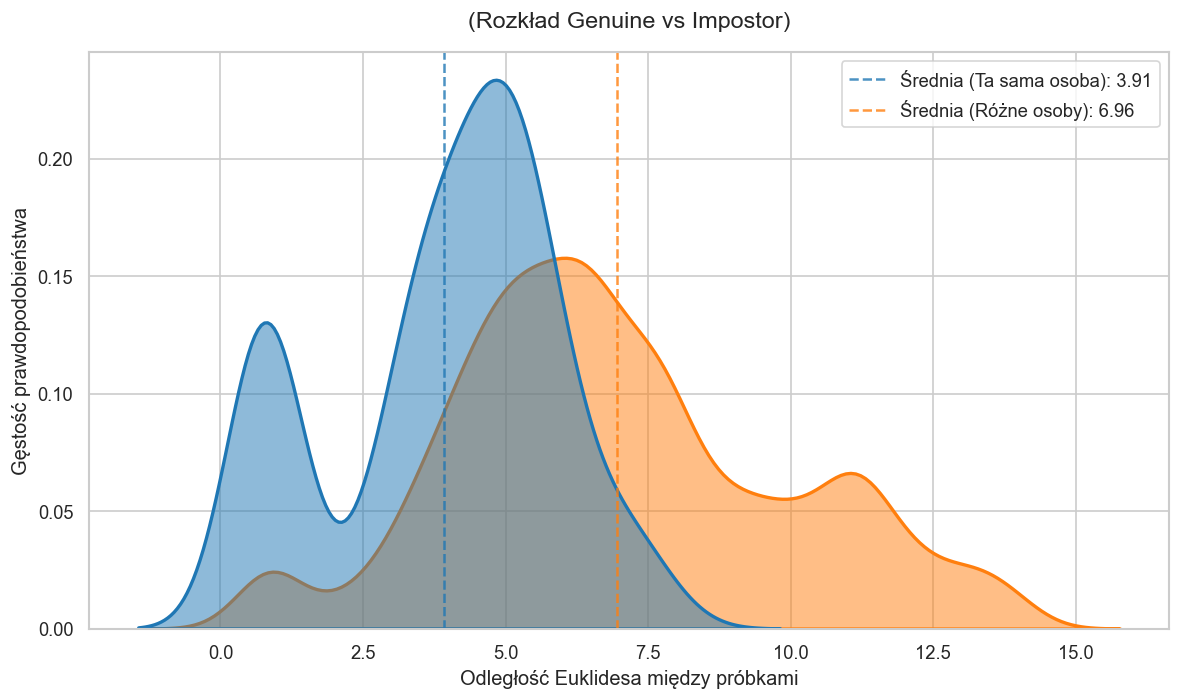

In [10]:
plt.figure(figsize=(10, 6), dpi=120)

sns.kdeplot(
    data=dist_df, 
    x='Euklides', 
    hue='Typ_Porównania', 
    fill=True, 
    common_norm=False, 
    palette=['#1f77b4', '#ff7f0e'],
    alpha=0.5,
    linewidth=2
)

plt.title("(Rozkład Genuine vs Impostor)", fontsize=14, pad=15)
plt.xlabel("Odległość Euklidesa między próbkami", fontsize=12)
plt.ylabel("Gęstość prawdopodobieństwa", fontsize=12)

mean_genuine = dist_df[dist_df['Typ_Porównania'] == 'Ta sama osoba']['Euklides'].mean()
mean_impostor = dist_df[dist_df['Typ_Porównania'] == 'Różne osoby']['Euklides'].mean()

plt.axvline(mean_genuine, color='#1f77b4', linestyle='--', alpha=0.8, label=f'Średnia (Ta sama osoba): {mean_genuine:.2f}')
plt.axvline(mean_impostor, color='#ff7f0e', linestyle='--', alpha=0.8, label=f'Średnia (Różne osoby): {mean_impostor:.2f}')

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()